In [3]:
!pip install librosa tensorflow numpy transformers soundfile tqdm

In [4]:
import tensorflow as tf
import numpy as np
import librosa, os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive
drive.mount('/content/drive')

# Load YAMNet from TensorFlow Hub
import tensorflow_hub as hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

SAMPLE_RATE = 16000  # Required by YAMNet
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']


Mounted at /content/drive


In [5]:
def extract_yamnet_features(file_path):
    try:
        waveform, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        scores, embeddings, spectrogram = yamnet_model(tf.convert_to_tensor(waveform))
        return np.mean(embeddings.numpy(), axis=0)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [6]:
DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/Data/genres_original"
features, labels = [], []

for genre in GENRES:
    genre_path = os.path.join(DATASET_PATH, genre)
    print(f"Processing {genre}...")
    for file in tqdm(os.listdir(genre_path)):
        if file.endswith((".wav", ".au")):
            fpath = os.path.join(genre_path, file)
            feat = extract_yamnet_features(fpath)
            if feat is not None:
                features.append(feat)
                labels.append(genre)

X = np.array(features)
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))


Processing blues...


100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


Processing classical...


100%|██████████| 100/100 [00:15<00:00,  6.33it/s]


Processing country...


...

100%|██████████| 100/100 [00:12<00:00,  8.11it/s]


Processing reggae...


100%|██████████| 100/100 [00:11<00:00,  8.66it/s]


Processing rock...


100%|██████████| 100/100 [00:12<00:00,  8.28it/s]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)


In [8]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(1024,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(len(GENRES), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)
model.save("yamnet_gtzan_final.h5")


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.4644 - loss: 1.7506 - val_accuracy: 0.8120 - val_loss: 0.5999
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7779 - loss: 0.6806 - val_accuracy: 0.8240 - val_loss: 0.5459
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8034 - loss: 0.5249 - val_accuracy: 0.8200 - val_loss: 0.5004
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8446 - loss: 0.4948 - val_accuracy: 0.8080 - val_loss: 0.5303
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8637 - loss: 0.4191 - val_accuracy: 0.8200 - val_loss: 0.5414
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8896 - loss: 0.3671 - val_accuracy: 0.8040 - val_loss: 0.5442
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8584 - loss: 0.3832 - val_accuracy: 0.8120 - val_loss: 0.5611
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8726 - loss: 0.3503 - val_accuracy: 0.8080 - val_los

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8127 - loss: 0.7160 
Test Accuracy: 82.40%


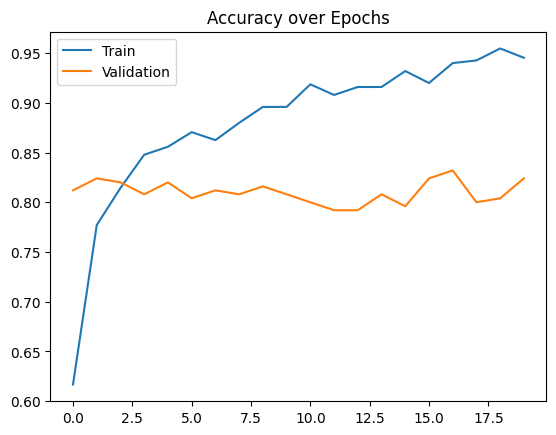

In [10]:
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2%}")

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()


In [11]:
!pip install transformers accelerate torch soundfile


In [12]:
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import torch
import soundfile as sf

processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
musicgen = MusicgenForConditionalGeneration.from_pretrained("facebook/musicgen-small")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

In [16]:
prompt = "a happy music"
inputs = processor(text=prompt, padding=True, return_tensors="pt")

audio_values = musicgen.generate(**inputs, max_new_tokens=256)
sf.write("generated_music.wav", audio_values[0, 0].numpy(), 32000)
print("Music generated and saved as generated_music.wav")


Music generated and saved as generated_music.wav
